# 📊 RRT

В этом ноутбуке проводится изучение RRT на случайно генерируемых гауссовых полях.

## Описание проекта

### 🎯 Цель исследования

Посмотреть поведение RRT и оценить его эффективность

по следующим метрикам:

- время выполнения
- количество посещённых и обработанных узлов
- длина найденного пути (евклидова и пиксельная)
- успешность нахождения пути
- максимальные углы в пути (вбок и продольный)
- минимальные расстояния до препятсвия (евклидово и пиксельное)

### 🧪 Методология

Для каждого запуска:

1. Генерируется поле фиксированного размера (1000x1000) с гаусами с случайными параметрами в заданых диапозонах.
2. Метрики записываются в CSV файл.
3. Максимально допустимые углы вперед/назад и вбок = 30 градусам
4. Всего 100 запусков

#### 📌 Важно

Так как число гауссов и размер карты не менятеся в экспериментах, и было большое число запусков, то их средние показатели ведут себя стабильно, поэтому их можно сравнить

### Задачи исследования

1. Загрузить библиотеки и таблицу
2. Небольшая очистка/подготовка данных
3. Базовая статистика
- Вывод

## Ход исследования

### 1) Загрузка библиотек и таблицы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# путь к CSV
path = "../var/metrics/rrt.csv"

df = pd.read_csv(path)

df.head()

,environment,algorithmName,executionTimeMs,pathNodes,expandedNodes,euclideanLength,pixelLength,pathFound,minObstacleDistance,minObstacleDistancePixel,maxSideAngle,maxUpDownAngle
0,continuous,RRT,1043.590,275,1917,1643.32,1409,1,4,4,29.6911,28.9399
1,continuous,RRT,18371.400,301,26458,1799.99,1547,1,2,2,29.7571,28.5045
2,continuous,RRT,998.330,282,1404,1686.23,1435,1,4,4,28.2326,26.7772
3,continuous,RRT,2073.890,282,4107,1682.30,1434,1,4,4,29.7204,24.4289
4,continuous,RRT,761.791,277,1444,1658.18,1430,1,4,4,28.9134,24.4708


In [2]:
graph = df[df["environment"] == "continuous"]
success = (
    graph.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count  mean  success_%
algorithmName                             
RRT            100    100   1.0      100.0


### 2) Небольшая очистка/подготовка

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   environment               100 non-null    object 
 1   algorithmName             100 non-null    object 
 2   executionTimeMs           100 non-null    float64
 3   pathNodes                 100 non-null    int64  
 4   expandedNodes             100 non-null    int64  
 5   euclideanLength           100 non-null    float64
 6   pixelLength               100 non-null    int64  
 7   pathFound                 100 non-null    int64  
 8   minObstacleDistance       100 non-null    int64  
 9   minObstacleDistancePixel  100 non-null    int64  
 10  maxSideAngle              100 non-null    float64
 11  maxUpDownAngle            100 non-null    float64
dtypes: float64(4), int64(6), object(2)
memory usage: 9.5+ KB


In [4]:
# приводим типы (на всякий случай)
df["executionTimeMs"] = df["executionTimeMs"].astype(float)
df["expandedNodes"] = df["expandedNodes"].astype(int)
df["pathNodes"] = df["pathNodes"].astype(int)
df["pathFound"] = df["pathFound"].astype(int)

df["euclideanLength"] = df["euclideanLength"].astype(float)
df["pixelLength"] = df["pixelLength"].astype(int)

df["minObstacleDistance"] = df["minObstacleDistance"].astype(float)
df["minObstacleDistancePixel"] = df["minObstacleDistancePixel"].astype(int)
df["maxSideAngle"] = df["maxSideAngle"].astype(float)
df["maxUpDownAngle"] = df["maxUpDownAngle"].astype(float)

In [5]:
# разделяем по алгоритмам
rrt = graph[graph["algorithmName"] == "RRT"].reset_index(drop=True)

In [6]:
mask = (
    (rrt["pathFound"] == 1)
)

rrt = rrt[mask].reset_index(drop=True)

In [7]:
graph_ok = pd.concat([rrt], ignore_index=True)

### 3) Базовая статистика


=========== executionTimeMs ===========
                   mean    median       std      min      max
algorithmName                                                
RRT            3555.926  1548.175  6933.641  287.044  55816.9


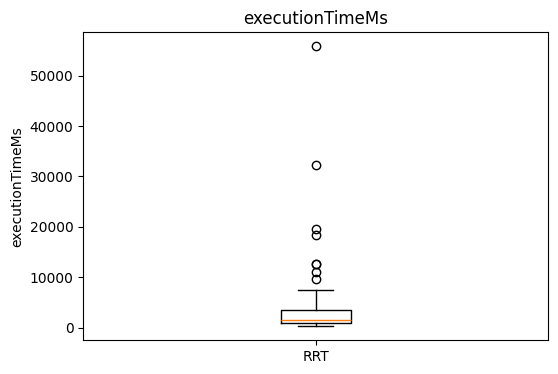


=========== expandedNodes ===========
                 mean  median       std  min    max
algorithmName                                      
RRT            5296.7  2983.5  7607.221  609  58226


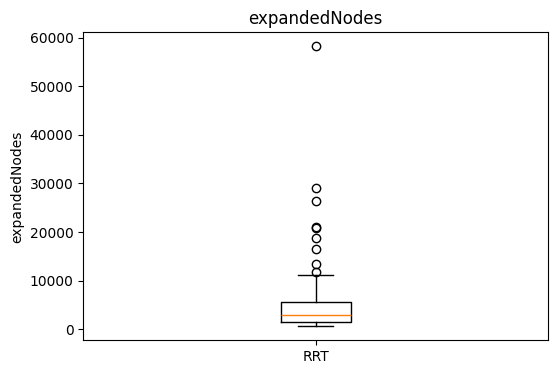


=========== pathNodes ===========
                 mean  median     std  min  max
algorithmName                                  
RRT            291.21   286.5  16.596  262  330


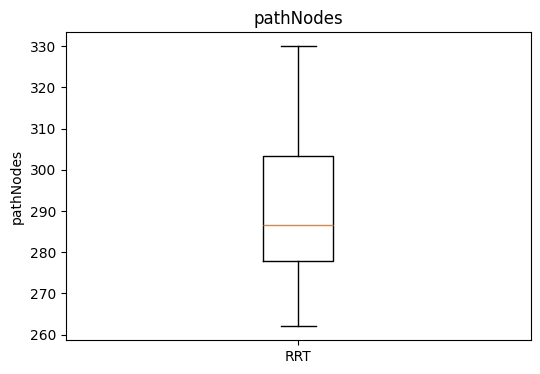


=========== euclideanLength ===========
                   mean  median     std      min      max
algorithmName                                            
RRT            1741.076  1713.1  99.319  1564.29  1971.09


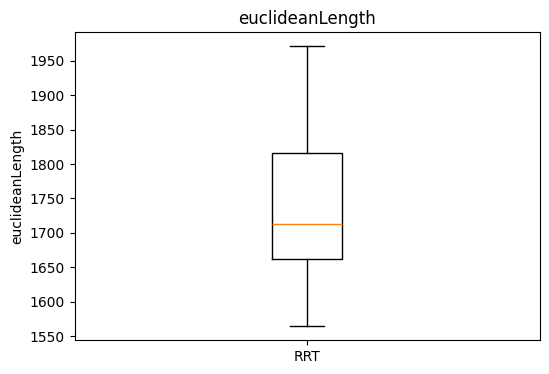


=========== pixelLength ===========
                  mean  median      std   min   max
algorithmName                                      
RRT            1498.28  1473.0  109.764  1304  1750


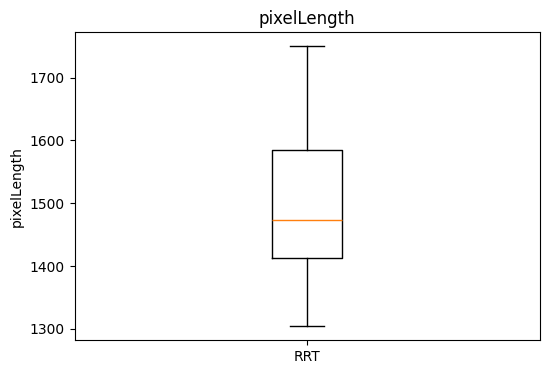


=========== minObstacleDistance ===========
               mean  median    std  min  max
algorithmName                               
RRT            3.62     4.0  0.789    2    4


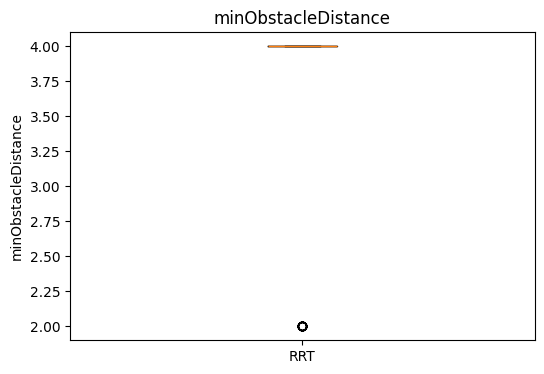


=========== minObstacleDistancePixel ===========
               mean  median    std  min  max
algorithmName                               
RRT            3.62     4.0  0.789    2    4


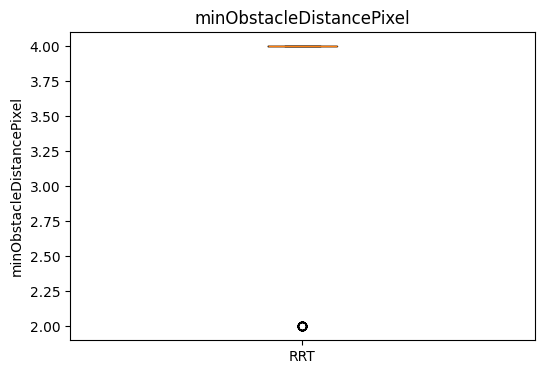


=========== maxSideAngle ===========
                 mean  median   std    min     max
algorithmName                                     
RRT            29.662   29.84  0.48  27.44  29.998


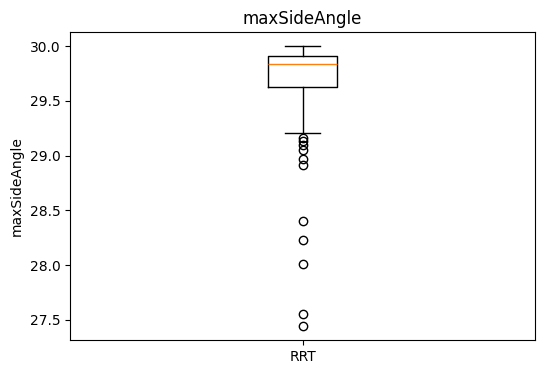


=========== maxUpDownAngle ===========
                 mean  median    std     min     max
algorithmName                                       
RRT            28.012  28.608  1.794  22.222  29.986


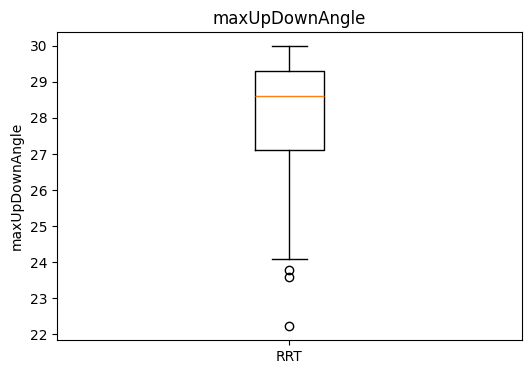

In [8]:
metrics = [
    "executionTimeMs",
    "expandedNodes",
    "pathNodes",
    "euclideanLength",
    "pixelLength",
    "minObstacleDistance",
    "minObstacleDistancePixel",
    "maxSideAngle",
    "maxUpDownAngle"
]

for metric in metrics:
    print(f"\n\033[1m=========== {metric} ===========\033[0m")

    summary = (
        graph_ok.groupby("algorithmName")[metric]
          .agg(["mean", "median", "std", "min", "max"])
          .round(3)
    )

    print(summary)
    plt.figure(figsize=(6, 4))

    plt.boxplot([
        rrt[metric]
    ], tick_labels=["RRT"])

    plt.title(metric)
    plt.ylabel(metric)

    plt.show()

#### Вывод

В ходе эксперимента было выполнено 100 запусков алгоритма RRT на случайно сгенерированных гауссовых полях размером 1000×1000. Во всех экспериментах алгоритм успешно находил путь от стартовой точки до конечной:

success=100%

Это показывает, что при выбранных параметрах алгоритм стабильно работает на рассматриваемом классе карт.

Среднее время выполнения составило:

3555.926 мс

при этом медианное значение значительно меньше:

1548.175 мс

Это говорит о наличии отдельных сложных случаев, в которых алгоритм исследует значительно большую часть пространства перед нахождением пути. Большое стандартное отклонение времени выполнения:

σ=6933.641 мс

подтверждает, что время работы RRT сильно зависит от конкретной конфигурации препятствий и случайного процесса построения дерева.

Количество обработанных вершин также имеет значительный разброс:

среднее количество расширенных узлов:
5296.7
медианное значение:
2983.5
максимальное:
58226

Таким образом, в большинстве случаев RRT строит относительно компактное дерево, однако на некоторых сложных картах может значительно расширять область поиска.

Количество вершин в найденном пути изменяется незначительно:

N
path
	​

=291.21±16.596

что говорит о стабильности структуры найденных решений. При этом длина пути имеет небольшой разброс:

Евклидова длина:

1741.076

Пиксельная длина:

1498.28

Полученные значения показывают, что RRT в среднем строит достаточно прямые пути, однако они не являются оптимальными, так как алгоритм ориентирован прежде всего на быстрое нахождение допустимого решения, а не на минимизацию длины.

Минимальное расстояние до препятствий во всех экспериментах оставалось небольшим:

d
min
	​

=3.62

При заданном радиусе безопасности и ограничениях столкновения алгоритм стабильно строил пути с небольшим запасом относительно препятствий.

Ограничения по углам также выполнялись во всех экспериментах:

максимальный боковой угол:
29.662
∘
максимальный продольный угол:
28.012
∘

При этом значения близки к установленному ограничению:

30
∘

Это показывает, что ограничение проходимости активно влияет на построение дерева и выбор допустимых направлений движения.

Общий вывод

Эксперимент показал, что RRT способен стабильно находить допустимые пути в непрерывных гауссовых полях даже при большом размере карты. Алгоритм продемонстрировал высокую успешность поиска, однако время выполнения сильно зависит от сложности конкретной карты.

Основной особенностью RRT является наличие редких сложных случаев, когда дерево значительно расширяется перед нахождением решения. При этом качество найденных путей остается достаточно стабильным, а ограничения столкновений и угловых характеристик выполняются.